In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, append = True)
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import numpy as np 

from tenpy.models.model import CouplingMPOModel, NearestNeighborModel
from tenpy.models.lattice import Chain
from tenpy.networks.site import SpinHalfSite, SpinHalfFermionSite, set_common_charges, GroupedSite

from fisher_lg.Kondo import KondoChain, KondoModel
from fisher_lg.State import State_Evo
import fisher_lg.tools as tls

from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO


The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [2]:
model_params = {
    'J_ei': -10 , 'J_ii': -0.1,  
    't' : 1,
    'L': 4,
    'symmetry_breaking_field' : 1.e-6,
    'bc': 'finite',
    'model_type' : "Kondo",
    'conserve' : 'Sz'
}
extra_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 60,
    'max_trunc_err' : 1e-8,
    'trunc_params': {
        'chi_max':  300,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-8
    },
    'verbose': False,
    'combine': True, #tebd params 
    'N_times' : 4,  #Only even N_times are used for K, 
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 3  #only an option for calculating the maximum of the LG correlator
}
psi_first = State_Evo.from_dmrg_search_Sz(model_params, extra_params)
psi1= psi_first.copy()
energy = psi_first.energy
energy1 = energy
deg_list = []
engy_list = []
sz_list = []

while np.abs(energy - energy1) < 5.e-3:
    
    deg_list += [psi1]
    engy_list += [energy1]
    sz_list += [round(np.mean(psi1.expectation_value('Sigmazi')), 4)]

    eng = dmrg.TwoSiteDMRGEngine(psi_first.copy(), psi_first.model, extra_params)
    eng.init_env(orthogonal_to = deg_list)
    energy1, psi1 = eng.run()
    
print( len(deg_list), sz_list , engy_list)


    

1 [np.float64(1.0)] [np.float64(-40.30000400000001)]


In [11]:
L = 4
chi_max = int( min(8 ** (L/2), 400))
op = 'Sigmazi'
num_sweeps = 60
t_end = 10
dt = 0.02

extra_params = {
   'mixer': False,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : num_sweeps,
    'max_trunc_err' : 1e-5,
    'E_tol_max' : 1e-6,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-6
    },
    'verbose': False,
    'combine': True,
    'N_times' : 2,  #Only even N_times are used for K,
    'dt': dt,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : t_end,  #only an option for calculating the maximum of the LG correlator
}
model_params = {
    'J_ei': -3. , 'J_ii': -0.1,  
    't' : 1.0,
    'L': L,
    'model_type' : "Kondo",
    'conserve' : None,
    'symmetry_breaking_field' : 1.e-5}
start2 = time.perf_counter()
psi_b = State_Evo.from_dmrg(model_params, extra_params)
psi_b.apply_Q_MPO('Smi', op_sum = False)
psi_b.canonical_form()
end2 = time.perf_counter()

print( end2 -start2 )


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=3.87e-04


0.00038708036031162964
804.2580002000323


5.564836974902997e-06


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=3.00e-04


0.00030031654798027706
9.947820429495778e-08
1.4958711944300436e-08
0.0


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=3.00e-04


0.0002996527613001316


...

1.132172689364888e-05


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=7.79e-05


7.786543885728435e-05
7.419038474066719e-08
5.7418179121408145e-09
0.0
2.048186923386842e-06
1.0832421333058221e-08
-0.5172413793103448 -0.5
3.5926245449381523e-06
1.7137871146051075e-06
1.7351453260527244e-08
2.3371164458623627e-08
0.0
1.277118313909979e-07
1.5032133142916562e-08
-0.3793103448275863 -0.5


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.17e-05


1.1719511254149809e-05
1.126495812853055e-06
7.0063796573190465e-09
3.6024535191542804e-08
0.0
3.2260567297510584e-07
2.195633689306095e-08
-0.2413793103448274 -0.5
2.5547284951536037e-07
8.444085413047417e-06
1.0604405601714948e-08
1.6677400971841385e-08
0.0
8.761579249505131e-07
6.358062085620653e-09
-0.10344827586206895 -0.5
1.3067991919039707e-07
1.7341385920955752e-07
1.242640197231374e-07
1.6324686621366626e-08
0.0
9.005980430896339e-07
8.05174968373755e-09
0.0344827586206895 -0.5
3.3970223705749692e-06
1.3500561344280093e-06
1.5850254501563778e-08
1.6503094416795084e-08
0.0
4.43420365469955e-06
1.2866239469636183e-08
0.1724137931034484 -0.5
6.310290575838486e-07
3.2582922962614826e-07
2.35863766777988e-08
1.7710799732978463e-08
0.0
4.920776921308612e-07
2.5324456566001797e-09
0.31034482758620685 -0.5
6.316446659207651e-07
3.8409390004914417e-07
2.5697303922697665e-08
1.6096912966953814e-08
0.0
2.733965272069216e-06
6.727216674205329e-08
0.4482758620689653 -0.5
2.4839015243231473

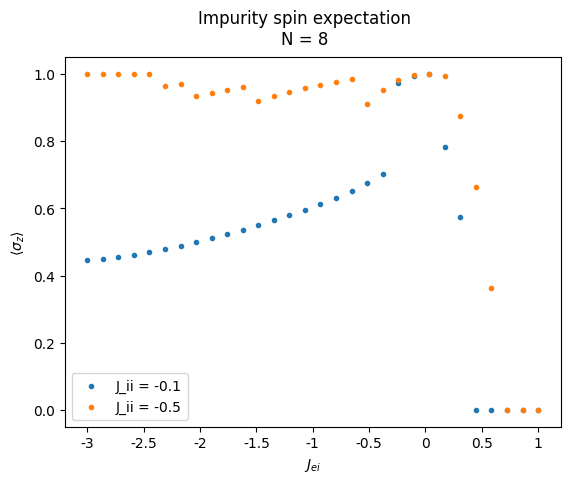

In [13]:
L = 8
chi_max = int( min(8 ** (L/2), 400))
op = 'Sigmazi'
num_points = 30
t_end = 10
dt = 0.02

fig, ax = plt.subplots(1)

extra_params = {
   'mixer': False,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-5,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-6
    },
    'verbose': False,
    'combine': True,
    'N_times' : 2,  #Only even N_times are used for K,
    'dt': dt,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : t_end,  #only an option for calculating the maximum of the LG correlator
}

jei_range = np.linspace(-3, 1, num_points)
jii_range = [-0.1, -0.5] #[-.1, -.5, -1, -2]

psi_init = None

for j_ii in jii_range:
    expe = []
    expe1 = []
    for j_ei in jei_range:
        model_params = {
            'J_ei': j_ei , 'J_ii': j_ii,  
            't' : 1.0,
            'L': L,
            'model_type' : "Kondo",
            'conserve' : 'Sz',
            'symmetry_breaking_field' : 1.e-5}

        psi_b = State_Evo.from_dmrg_search_Sz(model_params, extra_params)
        print(j_ei, j_ii)
        expe1 += [np.mean(psi_b.expectation_value(op))]


    ax.scatter(jei_range, expe1, marker = '.', label = "J_ii = " + str(j_ii), zorder = 3)


fig.suptitle("Impurity spin expectation\nN = " + str(L))
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("$J_{ei}$")
ax.set(ylabel = "$\\langle \\sigma_z \\rangle$")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()



In [14]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\Kondo\\Kondo_L8_Zi_expectation_Jei_zoom.png")

In [ ]:
L = 4
chi_max = int( min(8 ** (L/2), 400))
op = 'Sigmazi'
op_sum = False
num_points = 60
t_end = .5
dt = 0.01
j_ii = -.5

extra_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-5,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-6
    },
    'verbose': False,
    'combine': True,
    'N_times' : 2,  #Only even N_times are used for K,
    'dt': dt,'N_steps': 1,
    'order': 2,
    'start_time' : 0  ,
    't_max' : t_end,  #only an option for calculating the maximum of the LG correlator
}


theta_range = np.linspace(-3, 3, num_points)

fig, ax = plt.subplots(1)
bar = tls.ProgressBar(min_value = theta_range[0], max_value = theta_range[-1])
            
LG_bound = []
QFI_lst =[]
for theta in theta_range:
    model_params = {
    'J_ei':  theta , 'J_ii': j_ii,  #J_ei =1   J_ii pm,  J_ei=-1   J_ii pm
    't' : 1.0,
    'L': L,
    'model_type' : "Kondo",
    'conserve' : 'Sz',
    'symmetry_breaking_field' : 1.e-5} #conserve = None when not using from_dmrg_search_Sz

    psi_c = State_Evo.from_dmrg_search_Sz(model_params, extra_params)
    t_max, LG_max , qfi = psi_c.calculate_LG_bound(op, op_sum = op_sum, return_QFI= True)
    LG_bound += [LG_max]
    QFI_lst += [qfi]
    bar.update(theta)
    

ax.fill_between(theta_range, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range, QFI_lst, marker = '.', label = "QFI", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = $Z_i$ , N = " + str(L) + ", $J_{ii}= $" + str(j_ii))
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("$J_{ei}$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

 [================>.......................]  42.37% 

In [5]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\Kondo\\Kondo_L8_Jii-.5_Zi_QFI_Bound.png")

In [27]:
super(State_Evo, psi_c)

<super: fisher_lg.State.State_Evo,
        <fisher_lg.State.State_Evo at 0x1ac34cd7750>>

4.000000000000001


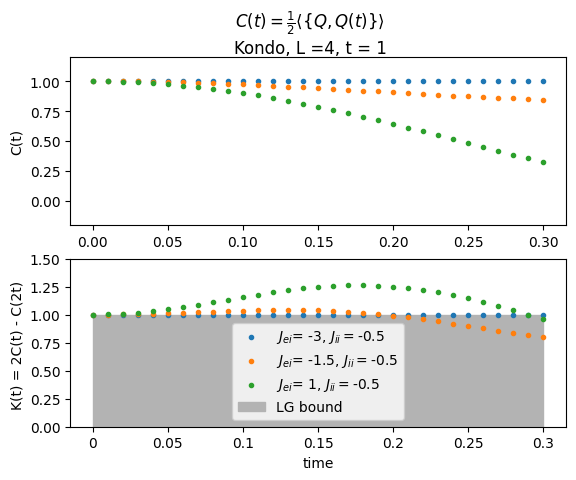

In [368]:
L = 4
chi_max = 220
op = 'Sigmazi'
op_sum = False
num_points = 30
t_end = .5
dt = 0.01
fig, ax = plt.subplots(2)

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-6,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-7
    },
    'verbose': False,
    'combine': True, #tebd params 
    'N_times' : num_points,
    'dt': dt,'N_steps': max(2*int( t_end//(2*dt * num_points)),1),
    'order': 2, 'start_time' : 0,
    't_max' : 30  #only an option for calculating the maximum of the LG correlator
    }
#[10, -.1], [5, -0.1], [1, -.1] t  = 3
Jg_lst = [ [-3, -.5], [-1.5, -.5], [1, -.5]]

for J_ei, J_ii in Jg_lst: 

    model_params = {
    'J_ei': J_ei , 'J_ii': J_ii,  
    't' : 1.0,
    'L': L,
    'bc_MPS': 'finite',
    'model_type' : "Kondo",
    'conserve' : None}

    psi = State_Evo.from_dmrg(model_params = model_params, dmrg_params = extra_params)
    
    times, Ct = psi.calculate_QtQ(op, op_sum = op_sum)
    ax[0].scatter(times, Ct, marker = '.', label = "$J_{ei} $= " + str(round(J_ei,2)) + ", $J_{ii}$ = " + str(round(J_ii,2)), zorder = 3)
    times, LG_correl, Kt = psi.calculate_LG_correlator(op, op_sum = op_sum)
    #ax[1].scatter(times, LG_correl, marker = '.', label = "$\\J = " + str(round(J_ei,2)) + ", h = " + str(round(J_ii,2)), zorder = 3)
    ax[1].scatter(times, Kt, marker = '.', label= "$J_{ei}$= " + str(round(J_ei,2)) + ", $J_{ii}=$" + str(round(J_ii,2)), zorder= 3)
ax[1].fill_between(times,-3, 1 ,  color = '.7', label = "LG bound "  )

print(psi.QFI(op, op_sum))

fig.suptitle("$C(t) = \\frac{1}{2}\\langle \\{Q, Q(t) \\}\\rangle$\nKondo, L =" + str(L) + ", t = 1")
ax[1].xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
#ax[1].set(ylabel = "2C(t) - C(2t) - C(0)")
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t) ")
ax[0].set_ylim([-.2 ,1.2])
ax[1].set_ylim([0,1.5])
plt.legend()

plt.show()

In [ ]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\Kondo_L10_C_K.png")